# Set-up

In [351]:
import os as _os
import sys as _sys
try:
    _bin_dir = _os.path.dirname(_sys.executable)
    _os.environ["PATH"] += _os.pathsep + _bin_dir
    from pybedtools import paths as _paths
    _paths._set_bedtools_path(_bin_dir)
except ImportError:
    raise ImportError(
        "Please install pybedtools (pip install pybedtools)"
    )

In [352]:
import os
import pyBigWig
import numpy as np
import pandas as pd
import tqdm.auto as tqdm

import matplotlib.pyplot as plt
import seaborn as sns
from eugene.plot.tracks import plot_tracks

import seqdata as sd
import xarray as xr
import seqpro as sp

import torch

In [353]:
def plot_tracks(
    tracks, 
    interval, 
    height=1.5, 
    colors=None,
    sharey=True,
):
  _, axes = plt.subplots(len(tracks), 1, figsize=(20, height * len(tracks)), sharex=True, sharey=sharey)
  if not isinstance(axes, np.ndarray):
    axes = [axes]
  for ax, (title, y) in zip(axes, tracks.items()):
    if colors is not None:
      ax.fill_between(np.linspace(interval["start"], interval["end"], num=len(y)), y, color=colors[title])
    else:
      ax.fill_between(np.linspace(interval["start"], interval["end"], num=len(y)), y)
    ax.set_title(title)
    sns.despine(top=True, right=True, bottom=True)
  ax.set_xlabel(f"{interval['chrom']}:{interval['start']}-{interval['end']}")
  plt.tight_layout()

In [354]:
import torch

def detect_cpg_sites(X):
    """
    Detect CpG sites in a one-hot encoded DNA sequence.

    Parameters
    ----------
    X : torch.Tensor
        One-hot encoded DNA sequence of shape (B, 4, L), where
        B is the batch size, 4 corresponds to [A, C, G, T], and
        L is the sequence length.

    Returns
    -------
    torch.Tensor
        Binary mask of shape (B, L), where 1 indicates a CpG site.
        A 1 at position `i` indicates a CpG on either the forward or reverse strand.
    """
    assert X.shape[1] == 4, "Second dimension must represent [A, C, G, T]"
    
    # Extract "C" and "G" channels
    C = X[:, 1, :]  # Channel for "C", shape (B, L)
    G = X[:, 2, :]  # Channel for "G", shape (B, L)
    
    # Detect forward CpG (C followed by G)
    forward_cpg_mask = C[:, :-1] * G[:, 1:]  # Shape: (B, L-1)

    # Create a binary mask for CpG positions
    cpg_mask = torch.zeros_like(C)  # Shape: (B, L)
    cpg_mask[:, :-1] += forward_cpg_mask  # Mark `C` positions
    cpg_mask[:, 1:] += forward_cpg_mask  # Mark `G` positions

    return cpg_mask

In [355]:
os.chdir('/cellar/users/aklie/data/datasets/SeqDatasets/HepG2_WGBS')

# Define the regions

In [408]:
chrom = 'chr2'
chromStart = 166965000
chromEnd =166970000
interval = dict(chrom=chrom, start=chromStart, end=chromEnd)

# CpG sites coverage

In [409]:
rep1_bw = pyBigWig.open('processed/ENCFF782HWK_HepG2_WGBS_CpG_sites_coverage_rep1.bigWig')
rep2_bw = pyBigWig.open('processed/ENCFF306UZK_HepG2_WGBS_CpG_sites_coverage_rep2.bigWig')

In [410]:
chrom_sizes = list(rep1_bw.chroms().items())

In [411]:
rep1_vals = np.nan_to_num(np.array(rep1_bw.values(chrom, chromStart, chromEnd)))
rep2_vals = np.nan_to_num(np.array(rep2_bw.values(chrom, chromStart, chromEnd)))

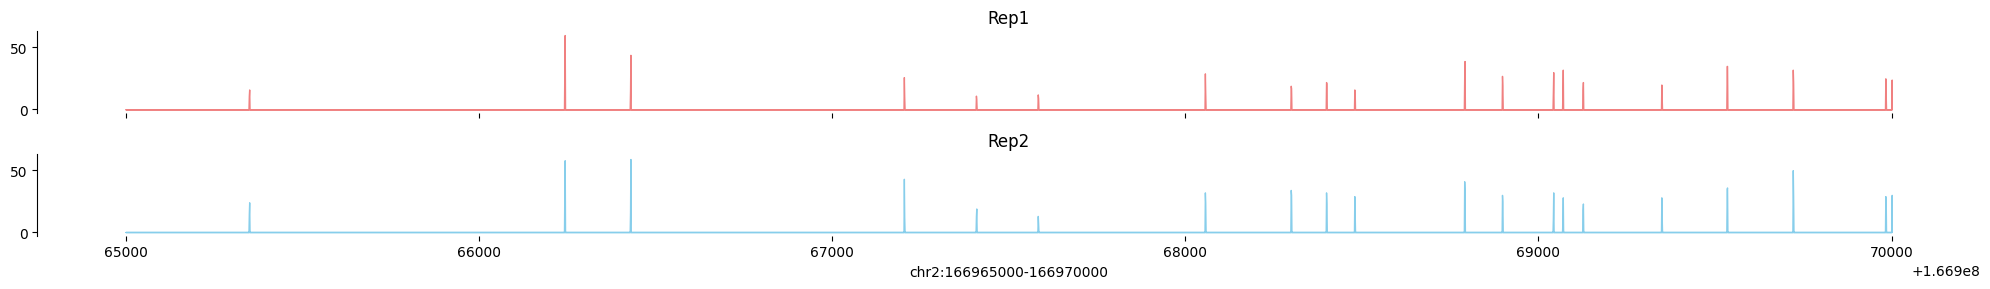

In [412]:
plot_tracks(
    tracks={
        'Rep1': rep1_vals,
        'Rep2': rep2_vals
    },
    interval=interval,
    colors={
        'Rep1': 'lightcoral',
        'Rep2': 'skyblue'
    }
)

In [413]:
# correlation
np.corrcoef(rep1_vals, rep2_vals)

array([[1.        , 0.97275449],
       [0.97275449, 1.        ]])

# CpG methylation state

In [ ]:
# Read first 1000 lines
# 1. Reference chromosome or scaffold
# 2. Start position in chromosome
# 3. End position in chromosome
# 4. Name of item
# 5. Score from 0-1000 (capped number of reads)
# 6. Strandedness: plus (+), minus (-), or unknown (.)
# 7. Start of where display should be thick (start codon)
# 8. End of where display should be thick (stop codon)
# 9. Color value (RGB)
# 10. Coverage, or number of reads
# 11. Percentage of reads that show methylation at this position in the genome

# Dont know what 11, 12, 13 are

BED_METHYL_SCHEMA = [
    'chrom', 'chromStart', 'chromEnd', 'name', 'score', 'strand', 'thickStart', 'thickEnd', 'itemRgb', 'coverage', 'methylation', '11', '12', '13'
]
rep1_bed = pd.read_csv('processed/ENCFF820ATI_HepG2_WGBS_CpG_methylation_state_rep1.bed.gz', sep='\t', header=None, names=BED_METHYL_SCHEMA)
rep2_bed = pd.read_csv('processed/ENCFF690FNR_HepG2_WGBS_CpG_methylation_state_rep2.bed.gz', sep='\t', header=None, names=BED_METHYL_SCHEMA)

In [61]:
rep1_bed["methylation_coverage"] = round((rep1_bed["methylation"]/100) * rep1_bed["coverage"], 0)
rep2_bed["methylation_coverage"] = (rep2_bed["methylation"]/100) * rep2_bed["coverage"]

In [62]:
# Remove any 0 coveraage rows
rep1_bed = rep1_bed[rep1_bed["methylation_coverage"] > 0]
rep2_bed = rep2_bed[rep2_bed["methylation_coverage"] > 0]
print(f"Number of non 0 rows: {len(rep1_bed)}")
print(f"Number of non 0 rows: {len(rep2_bed)}")

In [63]:
# Sort on chrom and chromStart
rep1_bed = rep1_bed.sort_values(["chrom", "chromStart"])
rep2_bed = rep2_bed.sort_values(["chrom", "chromStart"])

In [ ]:
for rep, bed in zip(['rep2'], [rep2_bed]):
    print(f"Writing bigwig for {rep}")
    bw = pyBigWig.open(f'processed/HepG2_WGBS_CpG_methylation_coverage_{rep}.bigWig', 'w')
    bw.addHeader(chrom_sizes, maxZooms=0)
    bw.addEntries(
        list(bed["chrom"].values.astype(str)), 
        list(bed["chromStart"].values), 
        ends=list(bed["chromEnd"].values), 
        values=bed["methylation_coverage"].values.astype("float64")
    )
    bw.close()

# Check

In [414]:
# Open bigwigs
rep1_bw_methyl = pyBigWig.open('processed/HepG2_WGBS_CpG_methylation_coverage_rep1.bigWig')
rep2_bw_methyl = pyBigWig.open('processed/HepG2_WGBS_CpG_methylation_coverage_rep2.bigWig')

In [415]:
# Get values
rep1_methyl_vals = np.nan_to_num(np.array(rep1_bw_methyl.values(chrom, chromStart, chromEnd)))
rep2_methyl_vals = np.nan_to_num(np.array(rep2_bw_methyl.values(chrom, chromStart, chromEnd)))

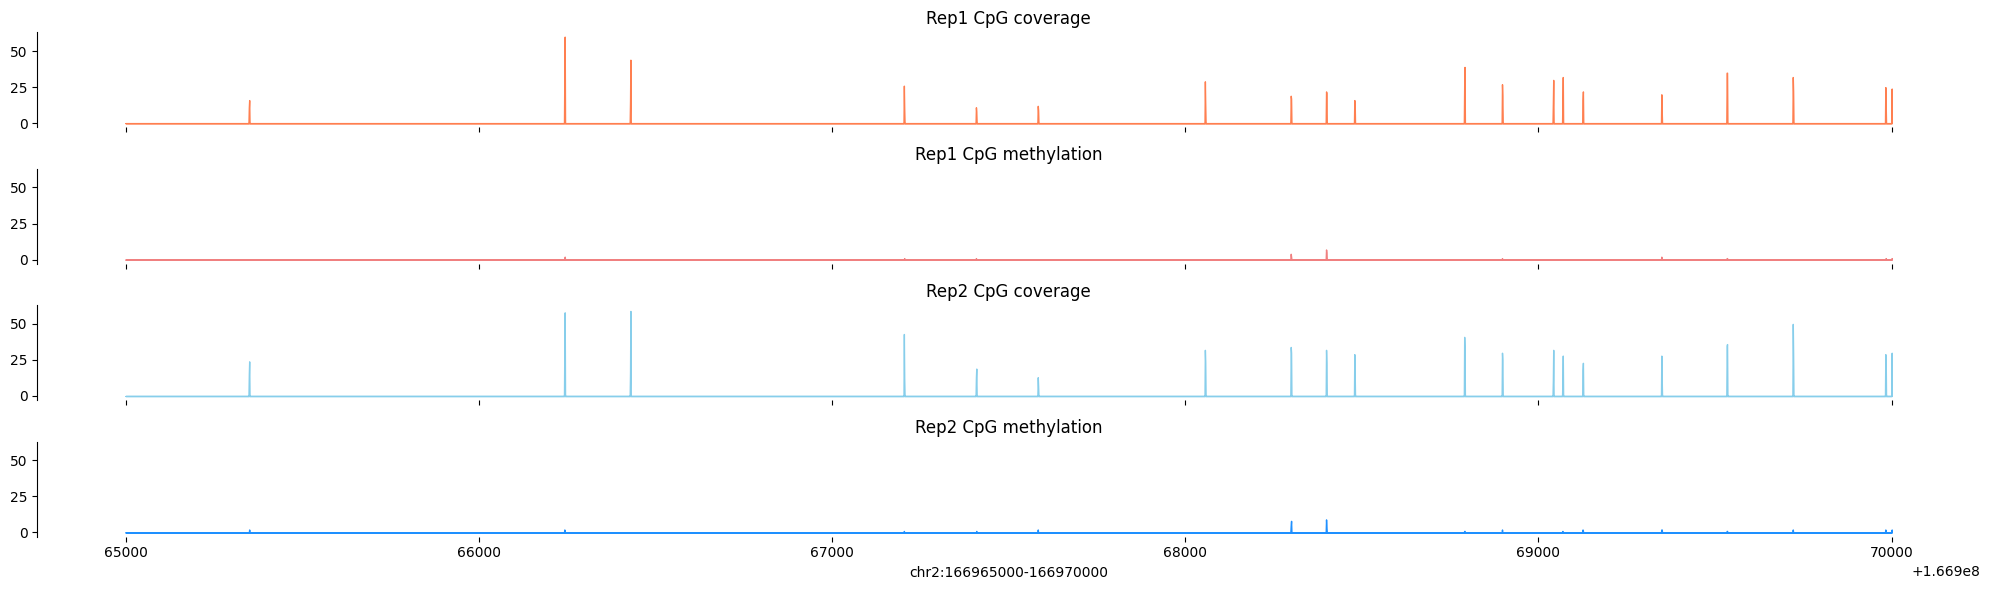

In [416]:
plot_tracks(
    tracks={
        'Rep1 CpG coverage': rep1_vals,
        'Rep1 CpG methylation': rep1_methyl_vals,
        'Rep2 CpG coverage': rep2_vals,
        'Rep2 CpG methylation': rep2_methyl_vals
    },
    interval=interval,
    colors={
        'Rep1 CpG coverage': 'coral',
        'Rep1 CpG methylation': 'lightcoral',
        'Rep2 CpG coverage': 'skyblue',
        'Rep2 CpG methylation': 'dodgerblue'
    },
    sharey=True
)

# SeqData

In [491]:
non_alphabet_proprtion = 0.1
min_cpg_coverage = 5
min_covered_cpgs = 25
min_covered_cpg_frac = 0.2

In [492]:
sdata = sd.open_zarr("/cellar/users/aklie/projects/ML4GLand/tutorials/bulk_wgbs_basepair/eugene/prep_dataset/5kb/HepG2_WGBS.minimal.seqdata")
sdata

<xarray.Dataset> Size: 28GB
Dimensions:     (_sequence: 617665, cov_sample: 2, _length: 5000)
Coordinates:
  * _sequence   (_sequence) <U11 27MB 'loci_0' 'loci_1' ... 'loci_617664'
  * cov_sample  (cov_sample) object 16B 'CpG_methylation_coverage_rep1' 'CpG_...
Dimensions without coordinates: _length
Data variables:
    chrom       (_sequence) object 5MB dask.array<chunksize=(77209,), meta=np.ndarray>
    chromEnd    (_sequence) int64 5MB dask.array<chunksize=(77209,), meta=np.ndarray>
    chromStart  (_sequence) int64 5MB dask.array<chunksize=(77209,), meta=np.ndarray>
    cov         (_sequence, cov_sample, _length) float32 25GB dask.array<chunksize=(10000, 1, 5000), meta=np.ndarray>
    fold_0      (_sequence) <U5 12MB dask.array<chunksize=(38605,), meta=np.ndarray>
    fold_1      (_sequence) <U5 12MB dask.array<chunksize=(38605,), meta=np.ndarray>
    fold_2      (_sequence) <U5 12MB dask.array<chunksize=(38605,), meta=np.ndarray>
    fold_3      (_sequence) <U5 12MB dask.array<chunksize=(38605,), meta=np.ndarray>
    fold_4      (_sequence) <U5 12MB dask.array<chunksize=(38605,), meta=np.ndarray>
    seq         (_sequence, _length) |S1 3GB dask.array<chunksize=(10000, 5000), meta=np.ndarray>
    strand      (_sequence) object 5MB dask.array<chunksize=(77209,), meta=np.ndarray>
    type        (_sequence) <U4 10MB dask.array<chunksize=(38605,), meta=np.ndarray>
Attributes:
    length_dim:    _length
    max_jitter:    0
    sequence_dim:  _sequence

In [493]:
seqs = sdata["seq"].values

## Filter out any sequences overlapping blacklisted regions

In [366]:
path_blacklist = "/cellar/users/aklie/data/ref/genomes/hg38/blacklist/blacklist.bed.gz"

In [440]:
sdata["blacklist_overlap"] = sd.label_overlapping_regions(
    sdata,
    targets=path_blacklist,
    mode="binary",
)

In [444]:
sdata["blacklist_overlap"].sum().values

array(14976, dtype=uint64)

In [446]:
blacklist_regions = np.where(sdata["blacklist_overlap"])[0]
print(f"Number of blacklisted regions: {len(blacklist_regions)}")

Number of blacklisted regions: 14976


## Filter out sequences with large proportion of Ns

In [370]:
seq_len = sp.length(seqs)
alphabet_cnt = sp.nucleotide_content(seqs, normalize=False, alphabet=sp.DNA, length_axis=-1)
non_alphabet_cnt = seq_len - alphabet_cnt.sum(axis=-1)

In [448]:
sdata["seq_length"] = xr.DataArray(seq_len, dims=["_sequence"])
sdata["non_alphabet_cnt"] = xr.DataArray(non_alphabet_cnt, dims=["_sequence"])

In [371]:
low_alphabet_regions = np.where(non_alphabet_cnt / seq_len > non_alphabet_proprtion)[0]
print(f"Number of low alphabet regions: {len(low_alphabet_regions)}")

Number of low alphabet regions: 33170


## Filter out regions with low numbers of covered CpGs

In [ ]:
# Total number of CpG sites in the regions
num_cpg_sites = []
batch_size = 10000
for i in tqdm.trange(0, sdata.dims["_sequence"], batch_size):
    ohes = torch.tensor(sp.ohe(sdata.seq[i:i+batch_size].values, alphabet=sp.DNA).transpose(0, 2, 1), dtype=torch.float32)
    num_cpg_sites.append(detect_cpg_sites(ohes).sum(dim=1).numpy())
num_cpg_sites = np.concatenate(num_cpg_sites)

/tmp/ipykernel_3556722/2912533469.py:4: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for i in tqdm.trange(0, sdata.dims["_sequence"], batch_size):


  0%|          | 0/62 [00:00<?, ?it/s]

In [494]:
# Num CpG sites covered (number of non 0 coverage sites)
num_cpg_sites_covered = (sdata.cov[:, 1, :] > min_cpg_coverage).sum(dim="_length").values

In [495]:
# Fraction of CpG sites covered
frac_cpg_sites_covered = np.nan_to_num(num_cpg_sites_covered / num_cpg_sites)

In [496]:
# Add to sdata
sdata["num_cpg_sites"] = xr.DataArray(num_cpg_sites, dims=["_sequence"])
sdata["num_cpg_sites_covered"] = xr.DataArray(num_cpg_sites_covered, dims=["_sequence"])
sdata["frac_cpg_sites_covered"] = xr.DataArray(frac_cpg_sites_covered, dims=["_sequence"])

In [497]:
not_enough_covered_cpgs = np.where(num_cpg_sites_covered < min_covered_cpgs)[0]
not_enough_covered_cpg_frac = np.where(frac_cpg_sites_covered < min_covered_cpg_frac)[0]
print(f"Number of regions with less than {min_covered_cpgs} covered CpG sites: {len(not_enough_covered_cpgs)}")
print(f"Number of regions with less than {100*min_covered_cpg_frac}% covered CpG sites: {len(not_enough_covered_cpg_frac)}")

Number of regions with less than 25 covered CpG sites: 158869
Number of regions with less than 20.0% covered CpG sites: 98607


# Check methylation fraction

In [501]:
total_cpg_coverage = sdata.cov[:, 1, :].sum(dim="_length").values
total_methylation_coverage =  sdata.cov[:, 0, :].sum(dim="_length").values
methyl_frac = np.nan_to_num(total_methylation_coverage / total_cpg_coverage)

In [503]:
# Add to sdata
sdata["total_cpg_coverage"] = xr.DataArray(total_cpg_coverage, dims=["_sequence"])
sdata["total_methylation_coverage"] = xr.DataArray(total_methylation_coverage, dims=["_sequence"])
sdata["methyl_frac"] = xr.DataArray(methyl_frac, dims=["_sequence"])

(array([51327., 24010., 28741., 30780., 29461., 28029., 25849., 23543.,
        21472., 19242., 17963., 16067., 14907., 13561., 12297., 11879.,
        11015., 10104.,  9285.,  8580.,  8077.,  7509.,  7044.,  6507.,
         5947.,  5988.,  5214.,  4958.,  4541.,  4088.,  4048.,  3770.,
         3586.,  3571.,  3434.,  3421.,  3494.,  3732.,  4066.,  4489.,
         5121.,  6147.,  7634.,  9687., 12934., 18214., 24319., 23026.,
         4705.,   282.]),
 array([0.        , 0.02      , 0.04      , 0.06      , 0.08      ,
        0.1       , 0.12      , 0.14      , 0.16      , 0.18000001,
        0.2       , 0.22      , 0.23999999, 0.25999999, 0.28      ,
        0.30000001, 0.31999999, 0.34      , 0.36000001, 0.38      ,
        0.40000001, 0.41999999, 0.44      , 0.46000001, 0.47999999,
        0.5       , 0.51999998, 0.54000002, 0.56      , 0.57999998,
        0.60000002, 0.62      , 0.63999999, 0.66000003, 0.68000001,
        0.69999999, 0.72000003, 0.74000001, 0.75999999, 0.77999997

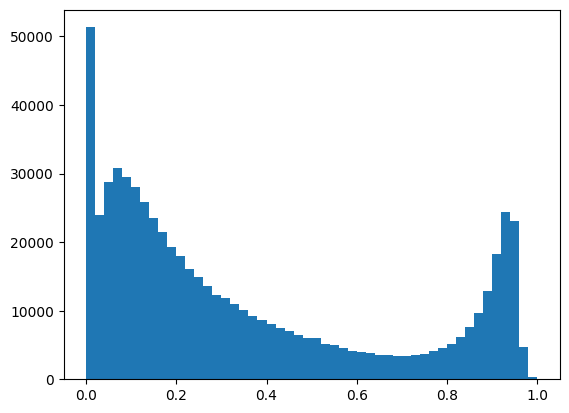

In [504]:
plt.hist(methyl_frac, bins=50)

In [505]:
good_regions = np.setdiff1d(
    np.arange(sdata.dims["_sequence"]),
    np.concatenate([blacklist_regions, low_alphabet_regions, not_enough_covered_cpgs, not_enough_covered_cpg_frac])
)
print(f"Number of good regions: {len(good_regions)}")

Number of good regions: 433183


/tmp/ipykernel_3556722/2440347395.py:2: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  np.arange(sdata.dims["_sequence"]),


In [506]:
good_sdata = sdata.isel(_sequence=good_regions)
good_sdata

<xarray.Dataset> Size: 20GB
Dimensions:                     (_sequence: 433183, cov_sample: 2, _length: 5000)
Coordinates:
  * _sequence                   (_sequence) <U11 19MB 'loci_36' ... 'loci_611...
  * cov_sample                  (cov_sample) object 16B 'CpG_methylation_cove...
Dimensions without coordinates: _length
Data variables: (12/18)
    chrom                       (_sequence) object 3MB dask.array<chunksize=(57389,), meta=np.ndarray>
    chromEnd                    (_sequence) int64 3MB dask.array<chunksize=(57389,), meta=np.ndarray>
    chromStart                  (_sequence) int64 3MB dask.array<chunksize=(57389,), meta=np.ndarray>
    cov                         (_sequence, cov_sample, _length) float32 17GB dask.array<chunksize=(6662, 1, 5000), meta=np.ndarray>
    fold_0                      (_sequence) <U5 9MB dask.array<chunksize=(24100,), meta=np.ndarray>
    fold_1                      (_sequence) <U5 9MB dask.array<chunksize=(24100,), meta=np.ndarray>
    ...                          ...
    num_cpg_sites               (_sequence) float32 2MB 346.0 106.0 ... 186.0
    num_cpg_sites_covered       (_sequence) int64 3MB 109 28 59 51 ... 78 117 99
    frac_cpg_sites_covered      (_sequence) float64 3MB 0.315 0.2642 ... 0.5323
    total_cpg_coverage          (_sequence) float32 2MB 2.197e+03 ... 4.048e+03
    total_methylation_coverage  (_sequence) float32 2MB 2.108e+03 ... 240.0
    methyl_frac                 (_sequence) float32 2MB 0.9595 ... 0.05929
Attributes:
    length_dim:    _length
    max_jitter:    0
    sequence_dim:  _sequence

In [515]:
sd.to_zarr(good_sdata, "/cellar/users/aklie/projects/ML4GLand/tutorials/bulk_wgbs_basepair/eugene/prep_dataset/5kb/HepG2_WGBS.minimal.filtered.seqdata")

/tmp/ipykernel_3556722/2834673162.py:1: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  seq_num = np.random.randint(0, good_sdata.dims["_sequence"])


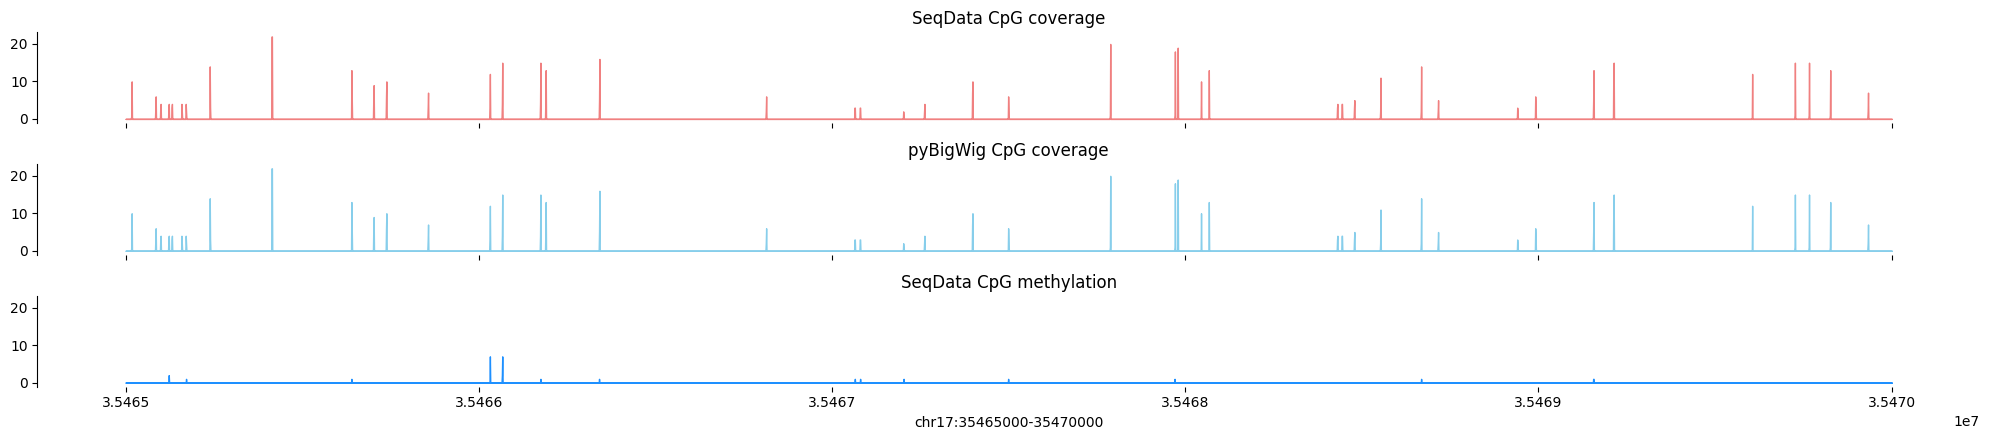

In [514]:
seq_num = np.random.randint(0, good_sdata.dims["_sequence"])
ser = good_sdata[["chrom", "chromStart", "chromEnd"]].to_dataframe().iloc[seq_num]
sdata_cov = good_sdata["cov"][seq_num, 1, :].values.squeeze()
sdata_methyl = good_sdata["cov"][seq_num, 0, :].values.squeeze()
pybw_vals = np.nan_to_num(np.array(rep1_bw.values(ser["chrom"], ser["chromStart"], ser["chromEnd"])))
chrom = ser["chrom"]
chromStart = ser["chromStart"]
chromEnd = ser["chromEnd"]
interval = dict(chrom=chrom, start=chromStart, end=chromEnd)
tracks = {
    "SeqData CpG coverage": sdata_cov,
    "pyBigWig CpG coverage": pybw_vals,
    "SeqData CpG methylation": sdata_methyl,
}
colors = {
    "SeqData CpG coverage": "lightcoral",
    "pyBigWig CpG coverage": "skyblue",
    "SeqData CpG methylation": "dodgerblue"
}

# Plot tracks
plot_tracks(
    tracks=tracks,
    interval=interval,
    colors=colors
)

In [460]:
sdata_cov[1000:1100]

array([ 0.,  0.,  0.,  0.,  0.,  0.,  0., 21.,  5.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., 22.,  3.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
       19.,  2.,  0.,  0.,  0.,  0.,  0.,  0.,  0.], dtype=float32)

In [461]:
sdata_methyl[1000:1100]

array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 2., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 7., 2., 0., 0., 0., 0., 0., 0., 0.],
      dtype=float32)

# DONE!

---

In [407]:
sdata.isel(_sequence=83185).chrom.values, sdata.isel(_sequence=83185).chromStart.values, sdata.isel(_sequence=83185).chromEnd.values

(array('chr2', dtype='<U4'), array(166965000), array(166970000))

In [401]:
np.where(frac_cpg_sites_covered > 1)

(array([ 83185, 443416, 446925, 446926]),)

In [48]:
low_cpg_regions = np.where(num_cpg_sites_covered < min_cpgs)[0]
print(f"Number of low CpG regions: {len(low_cpg_regions)}")

Number of low CpG regions: 185282


In [427]:
seq_num = 443416

In [428]:
seq = sdata.seq[seq_num].values
ohe = torch.tensor(sp.ohe(seq, alphabet=sp.DNA).transpose(), dtype=torch.float32)
cov = sdata.cov[seq_num, 1, :].values
cpg_sites = detect_cpg_sites(ohe.unsqueeze(0)).squeeze().numpy()
print(sdata.chrom[seq_num].values, sdata.chromStart[seq_num].values, sdata.chromEnd[seq_num].values)
for i in np.where(cov)[0]:
    curr_seq = ''.join([row.astype(str) for row in seq[i-1:i+2]])
    print(i, curr_seq)

chr14 25640000 25645000
0 
466 GCG
467 CGC
487 CCG
488 CGC
929 ACG
930 CGA
985 ACG
986 CGT
1025 CCG
1026 CGG
1108 ACG
1109 CGG
1609 TCG
1610 CGT
1688 TCG
1689 CGC
1873 ACG
1874 CGG
2023 CCG
2024 CGA
2444 ACG
2445 CGA
2477 TCG
2478 CGA
3068 TCG
3069 CGT
3265 TCG
3266 CGT
4063 GCG
4064 CGT
4314 CCG
4315 CGT
4984 CCG
4985 CGA


In [429]:
len(np.where(cov)[0])

35

In [430]:
seq[468:485]

array([b'C', b'C', b'T', b'G', b'A', b'A', b'A', b'C', b'T', b'G', b'T',
       b'C', b'T', b'C', b'A', b'T', b'T'], dtype='|S1')

In [431]:
len(np.where(cpg_sites.squeeze())[0])

34

/tmp/ipykernel_3556722/1095491243.py:4: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for i in tqdm.trange(0, sdata.dims["_sequence"], batch_size):


  0%|          | 0/62 [00:00<?, ?it/s]

In [41]:
median_cpg_coverage = total_cpg_coverage / num_cpg_sites

In [53]:
test = detect_cpg_sites(ohes)

In [56]:
test[0].sum()

tensor(27.)

In [ ]:
# Num CpG sites covered (number of non 0 coverage sites)
num_cpg_sites_covered = (sdata.cov[:, 1, :] > 0).sum(dim="_length").values

In [38]:
num_cpg_sites

array([  0.,   0., 193., ...,   0.,   0.,   0.], dtype=float32)

In [39]:
num_cpg_sites_covered

array([ 0,  0, 16, ...,  0,  0,  0])

In [40]:
total_cpg_coverage

array([ 0.,  0., 30., ...,  0.,  0.,  0.], dtype=float32)

In [23]:
avg_cpg_coverage = total_cpg_coverage / num_cpg_sites_covered

In [29]:
sdata.cov[1000, 1, :50].values

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 6., 8., 5., 5., 7., 8., 0., 0., 7., 8., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
      dtype=float32)

In [32]:
sdata.seq[1000, :50].values

array([b'T', b'C', b'T', b'T', b'T', b'G', b'G', b'T', b'G', b'T', b'C',
       b'T', b'G', b'T', b'G', b'T', b'G', b'T', b'G', b'T', b'G', b'C',
       b'G', b'C', b'G', b'C', b'G', b'C', b'A', b'C', b'G', b'T', b'G',
       b'C', b'A', b'T', b'G', b'T', b'G', b'T', b'G', b'T', b'G', b'A',
       b'G', b'T', b'T', b'G', b'T', b'C'], dtype='|S1')

In [54]:
avg_cpg_cov = total_cpg_coverage / num_cpg_sites_covered

In [ ]:
with sns.plotting_context("notebook", font_scale=1.5):
    sns.histplot(avg_cpg_cov, bins=100)
    plt.xlabel("Average CpG coverage")
    plt.ylabel("Number of 5kb regions")
    plt.title("Distribution of average CpG coverage in 5kb regions")

In [ ]:
# CpG coverage distribution
with sns.plotting_context("notebook", font_scale=1.5):
    sns.histplot(num_cpg_sites_covered, bins=100, kde=True)
    plt.xlabel("Number of CpG sites covered")
    plt.ylabel("Number of 5kb regions")
    plt.title("CpG coverage distribution")

In [ ]:
# How many 5kb regions have at least 30 coverage and 5 CpG sites
good_regions = (total_coverage >= min_cov) & (num_cpg_sites_covered >= min_cpgs)
good_regions.sum()

In [ ]:
total_coverage

In [ ]:
num_cpg_sites_covered

In [ ]:
good_regions

In [56]:
sdata_filt = sdata.sel(_sequence=good_regions)

In [ ]:
sdata_filt

In [ ]:
sdata_filt[['chrom', 'chromStart', 'chromEnd']].to_pandas()

In [ ]:
ser

In [ ]:
sdata_filt[["chrom", "chromStart", "chromEnd"]].to_dataframe()

In [ ]:
rep1_bw

In [ ]:
seq_num = 0
ser = sdata_filt[["chrom", "chromStart", "chromEnd"]].to_dataframe().iloc[seq_num]
sdata_vals = sdata_filt["cov"][seq_num, 1, :].values.squeeze()
pybw_vals = np.nan_to_num(np.array(rep1_bw.values(ser["chrom"], ser["chromStart"], ser["chromEnd"])))
chrom = ser["chrom"]
chromStart = ser["chromStart"]
chromEnd = ser["chromEnd"]
interval = dict(chrom=chrom, start=chromStart, end=chromEnd)
tracks = {
    "SeqData": sdata_vals,
    "pyBigWig": pybw_vals
}
colors = {
    "SeqData": "lightblue",
    "pyBigWig": "lightcoral"
}

# Plot tracks
plot_tracks(
    tracks=tracks,
    interval=interval,
    colors=colors
)

# DONE!

---

# Sanity checks

In [ ]:
rep1_bed["bw_cov"] = rep1_vals[rep1_bed.chromStart.values - 1]

In [ ]:
import seaborn as sns

In [ ]:
sns.scatterplot(x='coverage', y='bw_cov', data=rep1_bed)

In [ ]:
12*0.58